# Customer Segmentation (Task 2) — Mall Customers

**Goal**: Cluster customers into segments using annual income and spending score. The notebook includes scaling, visual exploration, K-Means clustering with optimal k selection, 2D visualization, and a DBSCAN bonus section.

## Dataset

- Kaggle dataset: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

📊 Mall Customer Segmentation Dataset – CSV Summary
| 🔎 **Category** | 📌 **Details (from CSV)** |
| --- | --- |
| 📂 **Total Customers (Rows)** | 200 |
| 📊 **Total Features (Columns)** | 5 |
| 🧾 **Column Names** | CustomerID, Gender, Age, Annual Income (k$), Spending Score (1-100) |
| 🔢 **Numerical Columns** | CustomerID, Age, Annual Income (k$), Spending Score (1-100) |
| 🔠 **Categorical Columns** | Gender |
| 🧹 **Missing Values** | 0 in all columns |
| ♻️ **Unique Values (per column)** | CustomerID: 200, Gender: 2, Age: 51, Income: 64, Spending: 84 |

We will focus on two numeric features:
- `Annual Income (k$)`
- `Spending Score (1-100)`

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

plt.style.use("seaborn-v0_8")

In [2]:
# Load dataset
csv_path = "/kaggle/input/customer-segmentation-tutorial-in-python/Mall_Customers.csv"

df = pd.read_csv(csv_path)
print("Shape:", df.shape)
df.head()

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Basic info, missing values, and duplicates
print("Columns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)

missing = df.isna().sum().sort_values(ascending=False)
print("\nMissing values:\n", missing)

print("\nDuplicate rows:", df.duplicated().sum())

Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data types:
 CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0


## Exploratory Data Analysis (EDA)

We explore distributions and relationships between income and spending score.


In [4]:
# Summary statistics for numeric columns
numeric_summary = df.select_dtypes(include=["number"]).describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0



| Statistic        | What It Means                     | How It Is Calculated                          |
|-----------------|-----------------------------------|-----------------------------------------------|
| count           | Number of non-missing values      | N (total values excluding NaN)                |
| mean            | Average value                     | (x1 + x2 + ... + xN) / N                      |
| std             | Standard deviation (spread)       | sqrt( Σ(xi - mean)² / (N - 1) )               |
| min             | Smallest value                    | min(x)                                        |
| 25% (Q1)        | 25th percentile                   | Value below which 25% of data falls           |
| 50% (median)    | Middle value                      | If N is even, average of two middle values    |
| 75% (Q3)        | 75th percentile                   | Value below which 75% of data falls           |
| max             | Largest value                     | max(x)                                        |


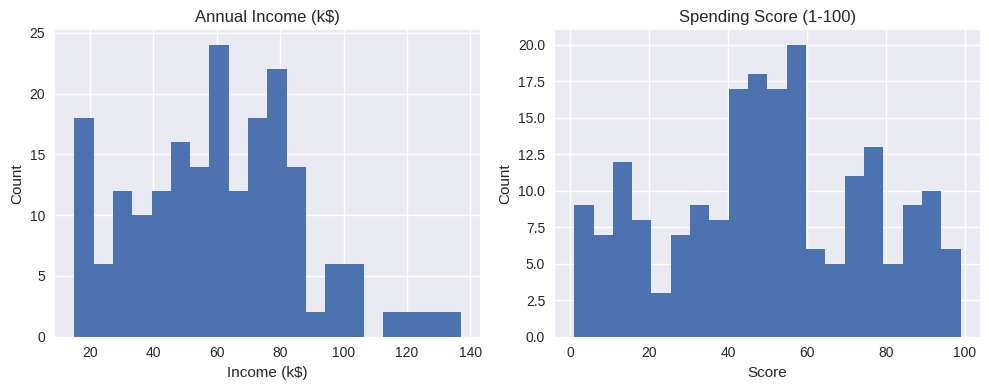

In [5]:
# Distributions of key features
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(df["Annual Income (k$)"], bins=20)
axes[0].set_title("Annual Income (k$)")
axes[0].set_xlabel("Income (k$)")
axes[0].set_ylabel("Count")

axes[1].hist(df["Spending Score (1-100)"], bins=20)
axes[1].set_title("Spending Score (1-100)")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

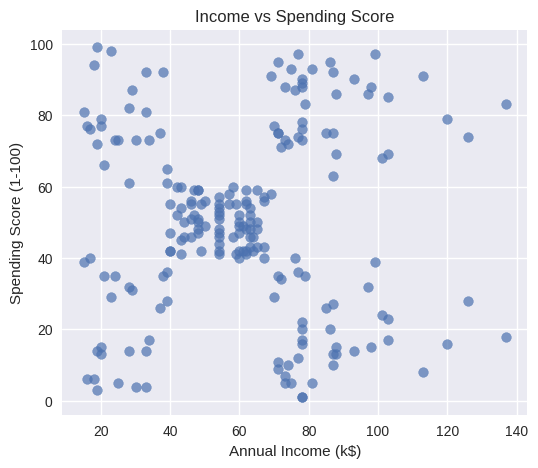

In [6]:
# 2D scatter (income vs spending score)
plt.figure(figsize=(6, 5))  #heigt  6 and width  5
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], alpha=0.7)
#Each dot = one customer.
#alpha=0.7 makes dots slightly transparent so overlap is visible.
plt.title("Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

Customers are not uniformly spread; they form visible groups.
* You can see clusters like:
* Low income – low spending (bottom‑left)
* Low income – high spending (top‑left)
* High income – low spending (bottom‑right)
* High income – high spending (top‑right)
* Mid income – mid spending (center)
  
 This visual pattern is why K‑Means clustering is useful here.

## Feature Selection and Scaling

We use `Annual Income (k$)` and `Spending Score (1-100)` for clustering, then scale them to equalize units.

In [7]:
# Select features for clustering
feature_cols = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[feature_cols].copy()

# Scale features
scaler = StandardScaler()
#(mean=0, std=1).

X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (200, 2)


## Find Optimal Number of Clusters (K)

We use the Elbow Method and Silhouette Score to decide the best K.

* Inertia = total within‑cluster distance (lower is better).
* On the plot, the “elbow point” is where the curve starts to flatten. That k is a good choice.


2) Silhouette Score
* For each k, labels are generated and silhouette score is calculated.
* Score ranges from -1 to +1.
* Higher value = better separation between clusters.

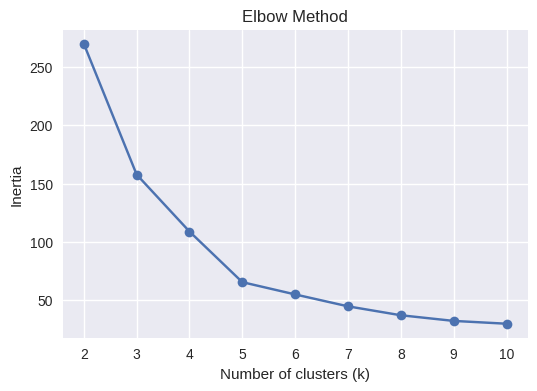

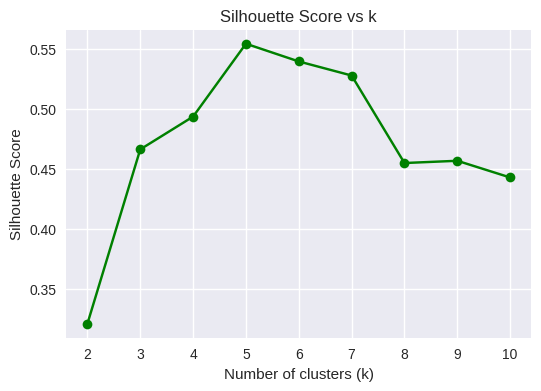

Best k by silhouette: 5


In [8]:
# Elbow method (Inertia)
ks = range(2, 11)
inertias = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(ks), inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()

# Silhouette scores
sil_scores = []
for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(6, 4))
plt.plot(list(ks), sil_scores, marker="o", color="green")
plt.title("Silhouette Score vs k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

best_k = list(ks)[int(np.argmax(sil_scores))]
print("Best k by silhouette:", best_k)


print("  Selects the k with the highest silhouette score.In this dataset, it prints: Best k by silhouette: 5.")

## K-Means Clustering

We train K-Means using the selected k and assign each customer to a cluster.

In [9]:
# Fit K-Means with the chosen k (you can override best_k if needed)
k_opt = best_k
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters
print("Cluster counts:\n", df["Cluster"].value_counts().sort_index())

df.head()

Cluster counts:
 Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [10]:
# Average spending score per cluster
cluster_spending = df.groupby("Cluster")["Spending Score (1-100)"].mean().sort_values(ascending=False)
cluster_spending



Cluster
1    82.128205
2    79.363636
0    49.518519
4    20.913043
3    17.114286
Name: Spending Score (1-100), dtype: float64

* Cluster 1: 82.13 (highest spenders)
* Cluster 2: 79.36 (high spenders)
* Cluster 0: 49.52 (medium spenders)
* Cluster 4: 20.91 (low spenders)
* Cluster 3: 17.11 (lowest spenders)

## Cluster Visualization (2D)

We visualize clusters on the Income vs Spending Score plane.

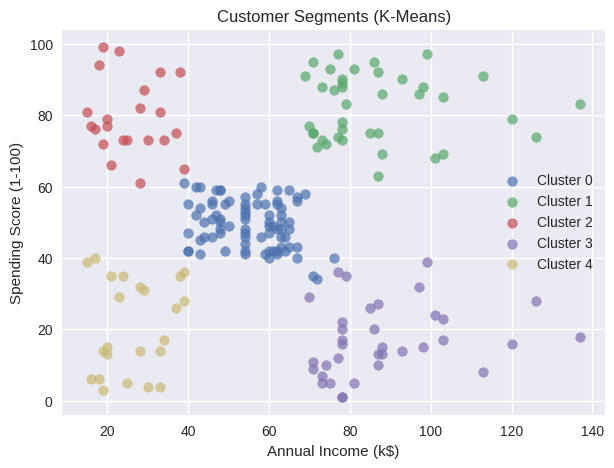

In [11]:
# 2D cluster plot
plt.figure(figsize=(7, 5))
for cluster_id in sorted(df["Cluster"].unique()):
    cluster_data = df[df["Cluster"] == cluster_id]
    plt.scatter(
        cluster_data["Annual Income (k$)"],
        cluster_data["Spending Score (1-100)"],
        label=f"Cluster {cluster_id}",
        alpha=0.7,
    )

plt.title("Customer Segments (K-Means)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

## Bonus: DBSCAN (Optional)

DBSCAN can find clusters with arbitrary shapes and also label noise points.

DBSCAN labels: [-1  0  1]
Counts: -1      8
 0    157
 1     35
Name: count, dtype: int64


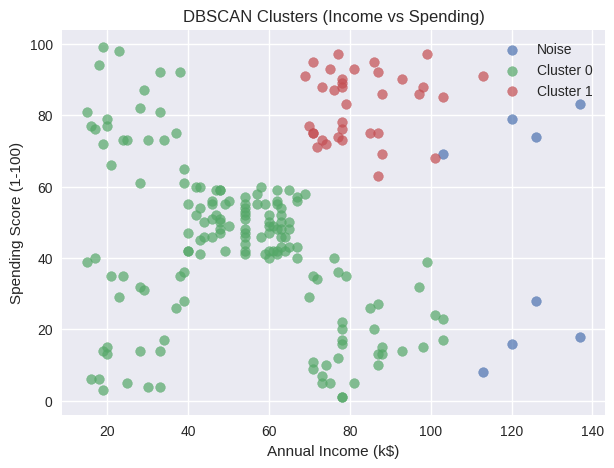

In [12]:
# DBSCAN clustering on scaled data
# You can tune eps and min_samples based on results

dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

unique_labels = np.unique(db_labels)
print("DBSCAN labels:", unique_labels)
print("Counts:", pd.Series(db_labels).value_counts().sort_index())

# Visualize DBSCAN result
plt.figure(figsize=(7, 5))
for label in unique_labels:
    mask = db_labels == label
    label_name = "Noise" if label == -1 else f"Cluster {label}"
    plt.scatter(
        df.loc[mask, "Annual Income (k$)"],
        df.loc[mask, "Spending Score (1-100)"],
        label=label_name,
        alpha=0.7,
    )

plt.title("DBSCAN Clusters (Income vs Spending)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

## Overall Summary

In this Task, we loaded the Mall Customers dataset and explored its basic structure. We visualized the distributions of annual income and spending score, then scaled these two features for fair clustering. Using the Elbow Method and Silhouette Score, we selected the optimal number of clusters and applied K-Means to segment customers. We visualized the segments on a 2D scatter plot and analyzed average spending per cluster to interpret the groups. As a bonus, we also tried DBSCAN to compare clustering behavior.